In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("variant_summary.txt",sep="\t",low_memory=False)

In [4]:
df.head(10)

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-
5,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-
6,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
7,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
8,15045,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),55572,FOXRED1,HGNC:26927,Likely pathogenic,1,"Jun 06, 2024",267606830,...,G,-,-,-,-,-,-,SCV005680614,-,-
9,15045,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),55572,FOXRED1,HGNC:26927,Likely pathogenic,1,"Jun 06, 2024",267606830,...,G,-,-,-,-,-,-,SCV005680614,-,-


In [5]:
df.columns

Index(['#AlleleID', 'Type', 'Name', 'GeneID', 'GeneSymbol', 'HGNC_ID',
       'ClinicalSignificance', 'ClinSigSimple', 'LastEvaluated', 'RS# (dbSNP)',
       'nsv/esv (dbVar)', 'RCVaccession', 'PhenotypeIDS', 'PhenotypeList',
       'Origin', 'OriginSimple', 'Assembly', 'ChromosomeAccession',
       'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele',
       'Cytogenetic', 'ReviewStatus', 'NumberSubmitters', 'Guidelines',
       'TestedInGTR', 'OtherIDs', 'SubmitterCategories', 'VariationID',
       'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF',
       'SomaticClinicalImpact', 'SomaticClinicalImpactLastEvaluated',
       'ReviewStatusClinicalImpact', 'Oncogenicity',
       'OncogenicityLastEvaluated', 'ReviewStatusOncogenicity',
       'SCVsForAggregateGermlineClassification',
       'SCVsForAggregateSomaticClinicalImpact',
       'SCVsForAggregateOncogenicityClassification'],
      dtype='str')

In [6]:
print(df.shape)
print(df.columns)

(8887816, 43)
Index(['#AlleleID', 'Type', 'Name', 'GeneID', 'GeneSymbol', 'HGNC_ID',
       'ClinicalSignificance', 'ClinSigSimple', 'LastEvaluated', 'RS# (dbSNP)',
       'nsv/esv (dbVar)', 'RCVaccession', 'PhenotypeIDS', 'PhenotypeList',
       'Origin', 'OriginSimple', 'Assembly', 'ChromosomeAccession',
       'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele',
       'Cytogenetic', 'ReviewStatus', 'NumberSubmitters', 'Guidelines',
       'TestedInGTR', 'OtherIDs', 'SubmitterCategories', 'VariationID',
       'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF',
       'SomaticClinicalImpact', 'SomaticClinicalImpactLastEvaluated',
       'ReviewStatusClinicalImpact', 'Oncogenicity',
       'OncogenicityLastEvaluated', 'ReviewStatusOncogenicity',
       'SCVsForAggregateGermlineClassification',
       'SCVsForAggregateSomaticClinicalImpact',
       'SCVsForAggregateOncogenicityClassification'],
      dtype='str')


In [7]:
df_snv = df[df['Type'] == 'single nucleotide variant']

In [8]:
df_snv['ClinicalSignificance'].unique()

<StringArray>
[                                                                      'Uncertain significance',
                                                                                   'Pathogenic',
                                                                            'Likely pathogenic',
                                                 'Conflicting classifications of pathogenicity',
                             'Conflicting classifications of pathogenicity; other; risk factor',
                                          'Conflicting classifications of pathogenicity; other',
                                                                                       'Benign',
                                                                 'Pathogenic/Likely pathogenic',
                                                                                  'risk factor',
                                                                                'Likely benign',
                

In [9]:
valid_labels = [
    "Benign",
    "Likely benign",
    "Pathogenic",
    "Likely pathogenic",
    "Pathogenic/Likely pathogenic","Benign/Likely benign"
]
df_clean = df_snv[df_snv["ClinicalSignificance"].isin(valid_labels)]

In [10]:
df_clean.head()

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
6,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
7,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
8,15045,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),55572,FOXRED1,HGNC:26927,Likely pathogenic,1,"Jun 06, 2024",267606830,...,G,-,-,-,-,-,-,SCV005680614,-,-
9,15045,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),55572,FOXRED1,HGNC:26927,Likely pathogenic,1,"Jun 06, 2024",267606830,...,G,-,-,-,-,-,-,SCV005680614,-,-
22,15053,single nucleotide variant,NM_000410.4(HFE):c.892+48G>A,3077,HFE,HGNC:4886,Benign,0,"Sep 11, 2018",1800758,...,A,-,-,-,-,-,-,SCV001844562,-,-


In [11]:
df_clean.columns


Index(['#AlleleID', 'Type', 'Name', 'GeneID', 'GeneSymbol', 'HGNC_ID',
       'ClinicalSignificance', 'ClinSigSimple', 'LastEvaluated', 'RS# (dbSNP)',
       'nsv/esv (dbVar)', 'RCVaccession', 'PhenotypeIDS', 'PhenotypeList',
       'Origin', 'OriginSimple', 'Assembly', 'ChromosomeAccession',
       'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele',
       'Cytogenetic', 'ReviewStatus', 'NumberSubmitters', 'Guidelines',
       'TestedInGTR', 'OtherIDs', 'SubmitterCategories', 'VariationID',
       'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF',
       'SomaticClinicalImpact', 'SomaticClinicalImpactLastEvaluated',
       'ReviewStatusClinicalImpact', 'Oncogenicity',
       'OncogenicityLastEvaluated', 'ReviewStatusOncogenicity',
       'SCVsForAggregateGermlineClassification',
       'SCVsForAggregateSomaticClinicalImpact',
       'SCVsForAggregateOncogenicityClassification'],
      dtype='str')

In [12]:
keep_columns =[
    "Type",
    "Name",
    "GeneSymbol",
    "ClinicalSignificance",
    "ReferenceAllele",
    "AlternateAllele",
    "Chromosome",
    "Start"
]
df_path_clean = df_clean[keep_columns]
df_path_clean.head()

,Type,Name,GeneSymbol,ClinicalSignificance,ReferenceAllele,AlternateAllele,Chromosome,Start
6,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126145284
7,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126275389
8,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126147412
9,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126277517
22,single nucleotide variant,NM_000410.4(HFE):c.892+48G>A,HFE,Benign,na,na,6,26093236


In [13]:
df_path_clean[["RefAA", "PositionAA", "AltAA"]] = df_path_clean["Name"].str.extract(
    r"\(p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})\)"
)

In [14]:
df_path_clean

,Type,Name,GeneSymbol,ClinicalSignificance,ReferenceAllele,AlternateAllele,Chromosome,Start,RefAA,PositionAA,AltAA
6,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126145284,Gln,232,Ter
7,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126275389,Gln,232,Ter
8,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126147412,Asn,430,Ser
9,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126277517,Asn,430,Ser
22,single nucleotide variant,NM_000410.4(HFE):c.892+48G>A,HFE,Benign,na,na,6,26093236,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8887800,single nucleotide variant,NM_000271.5(NPC1):c.2373+7T>C,NPC1,Likely pathogenic,na,na,18,21121263,NaN,NaN,NaN
8887801,single nucleotide variant,NM_000271.5(NPC1):c.2373+7T>C,NPC1,Likely pathogenic,na,na,18,23541299,NaN,NaN,NaN
8887802,single nucleotide variant,"SYCE1, IVS4, G-A, +1",SYCE1,Pathogenic,na,na,na,-1,NaN,NaN,NaN
8887805,single nucleotide variant,NM_001143764.3:c.271+2T>C,SYCE1,Pathogenic,na,na,na,-1,NaN,NaN,NaN


In [15]:
df_path_clean["ReferenceAllele"].unique()

<StringArray>
['na', '-', 'G', 'C', 'A', 'T']
Length: 6, dtype: str

In [16]:
df_path_clean = df_path_clean.dropna(subset=["RefAA","PositionAA","AltAA"])
df_path_clean = df_path_clean.drop_duplicates()
df_path_clean.head()

,Type,Name,GeneSymbol,ClinicalSignificance,ReferenceAllele,AlternateAllele,Chromosome,Start,RefAA,PositionAA,AltAA
6,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126145284,Gln,232,Ter
7,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,na,na,11,126275389,Gln,232,Ter
8,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126147412,Asn,430,Ser
9,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,na,na,11,126277517,Asn,430,Ser
30,single nucleotide variant,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,Pathogenic,na,na,6,26093443,Arg,330,Met


In [17]:
df_path_clean.drop(columns=["ReferenceAllele","AlternateAllele"], inplace=True)

In [18]:
df_path_clean.head()

,Type,Name,GeneSymbol,ClinicalSignificance,Chromosome,Start,RefAA,PositionAA,AltAA
6,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,11,126145284,Gln,232,Ter
7,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,11,126275389,Gln,232,Ter
8,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,11,126147412,Asn,430,Ser
9,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,11,126277517,Asn,430,Ser
30,single nucleotide variant,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,Pathogenic,6,26093443,Arg,330,Met


In [19]:
df = df_path_clean.drop_duplicates(subset=["GeneSymbol","RefAA","PositionAA","AltAA"])

In [20]:
df.head(10)

,Type,Name,GeneSymbol,ClinicalSignificance,Chromosome,Start,RefAA,PositionAA,AltAA
6,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,11,126145284,Gln,232,Ter
8,single nucleotide variant,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,11,126147412,Asn,430,Ser
30,single nucleotide variant,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,Pathogenic,6,26093443,Arg,330,Met
32,single nucleotide variant,NM_000410.4(HFE):c.848A>C (p.Gln283Pro),HFE,Pathogenic/Likely pathogenic,6,26093144,Gln,283,Pro
36,single nucleotide variant,NM_020779.4(WDR35):c.1844A>G (p.Glu615Gly),WDR35,Pathogenic,2,20145548,Glu,615,Gly
40,single nucleotide variant,NM_020779.4(WDR35):c.2590G>A (p.Ala864Thr),WDR35,Likely pathogenic,2,20133230,Ala,864,Thr
48,single nucleotide variant,NM_001042472.3(ABHD12):c.1054C>T (p.Arg352Ter),ABHD12,Pathogenic,20,25282958,Arg,352,Ter
54,single nucleotide variant,NM_138413.4(HOGA1):c.860G>T (p.Gly287Val),HOGA1,Pathogenic,10,99371292,Gly,287,Val
56,single nucleotide variant,NM_138413.4(HOGA1):c.289C>T (p.Arg97Cys),HOGA1,Pathogenic/Likely pathogenic,10,99358609,Arg,97,Cys
60,single nucleotide variant,NM_138413.4(HOGA1):c.209G>C (p.Arg70Pro),HOGA1,Pathogenic,10,99344669,Arg,70,Pro


In [21]:
df.shape

(276349, 9)

In [22]:
df.info()
df.shape

<class 'pandas.DataFrame'>
Index: 276349 entries, 6 to 8887798
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Type                  276349 non-null  str  
 1   Name                  276349 non-null  str  
 2   GeneSymbol            276349 non-null  str  
 3   ClinicalSignificance  276349 non-null  str  
 4   Chromosome            276349 non-null  str  
 5   Start                 276349 non-null  int64
 6   RefAA                 276349 non-null  str  
 7   PositionAA            276349 non-null  str  
 8   AltAA                 276349 non-null  str  
dtypes: int64(1), str(8)
memory usage: 21.1 MB


(276349, 9)

In [23]:
df.drop(columns=["Type"], inplace=True)


In [24]:
label_mapping  = {'Likely pathogenic':1, 'Pathogenic':1, 'Pathogenic/Likely pathogenic':1,
       'Benign':0, 'Benign/Likely benign':0, 'Likely benign':0}

In [25]:

df["Label"] = df["ClinicalSignificance"].map(label_mapping)

df.head()

,Name,GeneSymbol,ClinicalSignificance,Chromosome,Start,RefAA,PositionAA,AltAA,Label
6,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,Pathogenic,11,126145284,Gln,232,Ter,1
8,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,Likely pathogenic,11,126147412,Asn,430,Ser,1
30,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,Pathogenic,6,26093443,Arg,330,Met,1
32,NM_000410.4(HFE):c.848A>C (p.Gln283Pro),HFE,Pathogenic/Likely pathogenic,6,26093144,Gln,283,Pro,1
36,NM_020779.4(WDR35):c.1844A>G (p.Glu615Gly),WDR35,Pathogenic,2,20145548,Glu,615,Gly,1


In [26]:
df.drop(columns=['ClinicalSignificance'], inplace =True)

In [27]:
df.head()

,Name,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA,Label
6,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),FOXRED1,11,126145284,Gln,232,Ter,1
8,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,11,126147412,Asn,430,Ser,1
30,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,6,26093443,Arg,330,Met,1
32,NM_000410.4(HFE):c.848A>C (p.Gln283Pro),HFE,6,26093144,Gln,283,Pro,1
36,NM_020779.4(WDR35):c.1844A>G (p.Glu615Gly),WDR35,2,20145548,Glu,615,Gly,1


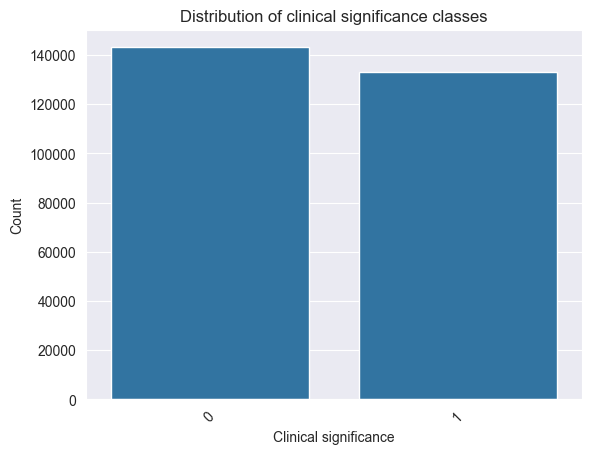

In [28]:
sns.countplot(data=df, x="Label")
plt.title("Distribution of clinical significance classes")
plt.xlabel("Clinical significance")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

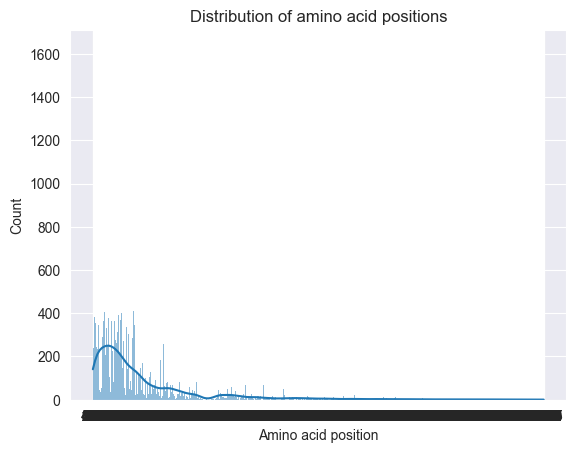

In [29]:
sns.histplot(data=df, x="PositionAA", bins=50, kde=True)
plt.title("Distribution of amino acid positions")
plt.xlabel("Amino acid position")
plt.ylabel("Count")
plt.show()

In [30]:
df[df['Label']==1].count()

Name          133174
GeneSymbol    133174
Chromosome    133174
Start         133174
RefAA         133174
PositionAA    133174
AltAA         133174
Label         133174
dtype: int64

In [31]:
df[df['Label']==0].count()


Name          143175
GeneSymbol    143175
Chromosome    143175
Start         143175
RefAA         143175
PositionAA    143175
AltAA         143175
Label         143175
dtype: int64

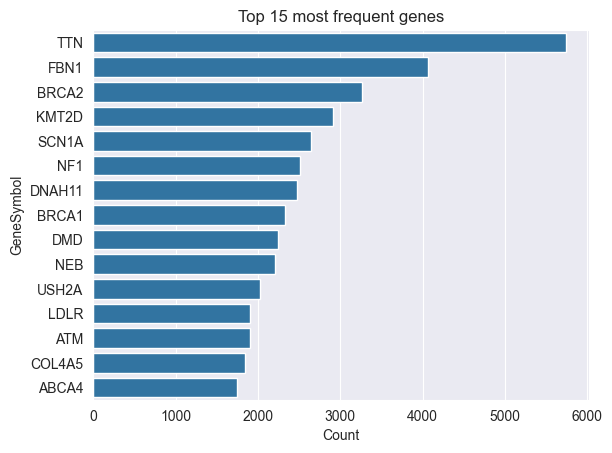

In [32]:
top_genes = df_path_clean["GeneSymbol"].value_counts().head(15)
sns.barplot(x=top_genes.values, y=top_genes.index)
plt.title("Top 15 most frequent genes")
plt.xlabel("Count")
plt.ylabel("GeneSymbol")
plt.show()

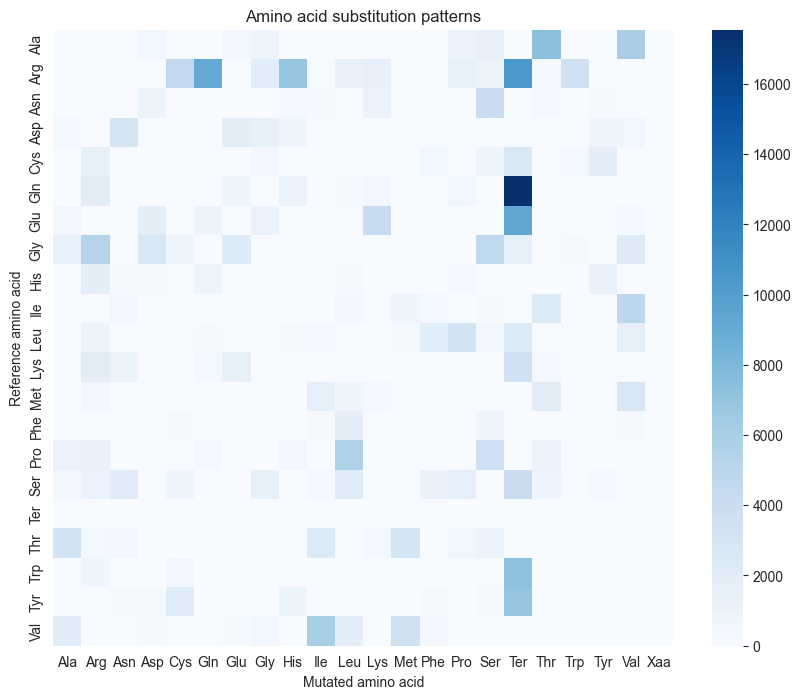

In [33]:
mutation_table = pd.crosstab(df["RefAA"], df["AltAA"])
plt.figure(figsize=(10, 8))
sns.heatmap(mutation_table, cmap="Blues")
plt.title("Amino acid substitution patterns")
plt.xlabel("Mutated amino acid")
plt.ylabel("Reference amino acid")
plt.show()

In [34]:
# aa_properties = {
# 'Ala': {'hydrophobic':1,'charge':0,'polar':0},
# 'Arg': {'hydrophobic':0,'charge':1,'polar':1},
# 'Asn': {'hydrophobic':0,'charge':0,'polar':1},
# 'Asp': {'hydrophobic':0,'charge':-1,'polar':1},
# 'Cys': {'hydrophobic':1,'charge':0,'polar':0},
# 'Gln': {'hydrophobic':0,'charge':0,'polar':1},
# 'Glu': {'hydrophobic':0,'charge':-1,'polar':1},
# 'Gly': {'hydrophobic':1,'charge':0,'polar':0},
# 'His': {'hydrophobic':0,'charge':1,'polar':1},
# 'Ile': {'hydrophobic':1,'charge':0,'polar':0},
# 'Leu': {'hydrophobic':1,'charge':0,'polar':0},
# 'Lys': {'hydrophobic':0,'charge':1,'polar':1},
# 'Met': {'hydrophobic':1,'charge':0,'polar':0},
# 'Phe': {'hydrophobic':1,'charge':0,'polar':0},
# 'Pro': {'hydrophobic':1,'charge':0,'polar':0},
# 'Ser': {'hydrophobic':0,'charge':0,'polar':1},
# 'Thr': {'hydrophobic':0,'charge':0,'polar':1},
# 'Trp': {'hydrophobic':1,'charge':0,'polar':0},
# 'Tyr': {'hydrophobic':0,'charge':0,'polar':1},
# 'Val': {'hydrophobic':1,'charge':0,'polar':0}
# }

In [55]:
df = df[
    (df_path_clean["RefAA"] != "Ter") &
    (df_path_clean["AltAA"] != "Ter")
]
df = df[
    (df_path_clean["RefAA"] != "Xaa") &
    (df_path_clean["AltAA"] != "Xaa")
]

C:\Users\tedip\AppData\Local\Temp\ipykernel_8384\2431789632.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[
C:\Users\tedip\AppData\Local\Temp\ipykernel_8384\2431789632.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[


In [56]:
# df.head()

In [57]:
# df["Ref_charge"] = df["RefAA"].map(lambda x: aa_properties[x]["charge"])
# df["Alt_charge"] = df["AltAA"].map(lambda x: aa_properties[x]["charge"])
# df["Ref_hydrophobic"] = df["RefAA"].map(lambda x: aa_properties[x]["hydrophobic"])
# df["Alt_hydrophobic"] = df["AltAA"].map(lambda x: aa_properties[x]["hydrophobic"])
# df["Ref_polarity"] = df["RefAA"].map(lambda x: aa_properties[x]["polar"])
# df["Alt_polarity"] = df["AltAA"].map(lambda x: aa_properties[x]["polar"])

In [58]:
df.head()

,Name,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA,Label
8,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,11,126147412,Asn,430,Ser,1
30,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,6,26093443,Arg,330,Met,1
32,NM_000410.4(HFE):c.848A>C (p.Gln283Pro),HFE,6,26093144,Gln,283,Pro,1
36,NM_020779.4(WDR35):c.1844A>G (p.Glu615Gly),WDR35,2,20145548,Glu,615,Gly,1
40,NM_020779.4(WDR35):c.2590G>A (p.Ala864Thr),WDR35,2,20133230,Ala,864,Thr,1


In [59]:
# df["charge_change"] = df["Alt_charge"] - df["Ref_charge"]
# df["hydrophobic_change"] = df["Alt_hydrophobic"] - df["Ref_hydrophobic"]

In [60]:
df.columns

Index(['Name', 'GeneSymbol', 'Chromosome', 'Start', 'RefAA', 'PositionAA',
       'AltAA', 'Label'],
      dtype='str')

In [61]:
df_tt = df.drop(columns=["Name"])



In [62]:
df_tt.head()

,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA,Label
8,FOXRED1,11,126147412,Asn,430,Ser,1
30,HFE,6,26093443,Arg,330,Met,1
32,HFE,6,26093144,Gln,283,Pro,1
36,WDR35,2,20145548,Glu,615,Gly,1
40,WDR35,2,20133230,Ala,864,Thr,1


In [63]:
df.head()

,Name,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA,Label
8,NM_017547.4(FOXRED1):c.1289A>G (p.Asn430Ser),FOXRED1,11,126147412,Asn,430,Ser,1
30,NM_000410.4(HFE):c.989G>T (p.Arg330Met),HFE,6,26093443,Arg,330,Met,1
32,NM_000410.4(HFE):c.848A>C (p.Gln283Pro),HFE,6,26093144,Gln,283,Pro,1
36,NM_020779.4(WDR35):c.1844A>G (p.Glu615Gly),WDR35,2,20145548,Glu,615,Gly,1
40,NM_020779.4(WDR35):c.2590G>A (p.Ala864Thr),WDR35,2,20133230,Ala,864,Thr,1


In [64]:
X = df_tt.drop('Label', axis =1)

In [65]:
X

,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA
8,FOXRED1,11,126147412,Asn,430,Ser
30,HFE,6,26093443,Arg,330,Met
32,HFE,6,26093144,Gln,283,Pro
36,WDR35,2,20145548,Glu,615,Gly
40,WDR35,2,20133230,Ala,864,Thr
...,...,...,...,...,...,...
8887790,MED13L,12,116450612,Ser,424,Pro
8887792,DYNC2H1,11,103024092,Lys,1053,Glu
8887794,WAC,10,28884704,Gln,218,Arg
8887796,CUX1,7,101740676,Leu,101,Ile


In [66]:
Y = df_tt['Label']

In [67]:
Y

8          1
30         1
32         1
36         1
40         1
          ..
8887790    0
8887792    0
8887794    0
8887796    0
8887798    0
Name: Label, Length: 209899, dtype: int64

In [68]:
Y.value_counts(normalize=True)

Label
0    0.679093
1    0.320907
Name: proportion, dtype: float64

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [70]:
X

,GeneSymbol,Chromosome,Start,RefAA,PositionAA,AltAA
8,FOXRED1,11,126147412,Asn,430,Ser
30,HFE,6,26093443,Arg,330,Met
32,HFE,6,26093144,Gln,283,Pro
36,WDR35,2,20145548,Glu,615,Gly
40,WDR35,2,20133230,Ala,864,Thr
...,...,...,...,...,...,...
8887790,MED13L,12,116450612,Ser,424,Pro
8887792,DYNC2H1,11,103024092,Lys,1053,Glu
8887794,WAC,10,28884704,Gln,218,Arg
8887796,CUX1,7,101740676,Leu,101,Ile


In [71]:
X.info()

<class 'pandas.DataFrame'>
Index: 209899 entries, 8 to 8887798
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   GeneSymbol  209899 non-null  str  
 1   Chromosome  209899 non-null  str  
 2   Start       209899 non-null  int64
 3   RefAA       209899 non-null  str  
 4   PositionAA  209899 non-null  str  
 5   AltAA       209899 non-null  str  
dtypes: int64(1), str(5)
memory usage: 11.2 MB


In [72]:
categorical_cols = [
"GeneSymbol",
"Chromosome",
"RefAA",
"PositionAA",
"AltAA"
]

numeric_cols = [
"Start"
]

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
)

In [74]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)

(167919, 21454)
(41980, 21454)


In [75]:
X_train_processed

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 6.71094250e+07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 2.32938540e+07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 9.96701600e+07],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.53531400e+06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.35786426e+08],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.72379590e+07]],
      shape=(167919, 21454))

In [76]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [77]:
y_pred_log = log_reg_pipeline.predict(X_test)
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.4054787994282992

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.16      0.27     28508
           1       0.34      0.92      0.50     13472

    accuracy                           0.41     41980
   macro avg       0.58      0.54      0.38     41980
weighted avg       0.66      0.41      0.34     41980



In [79]:
cm = confusion_matrix(y_test, y_pred_log)

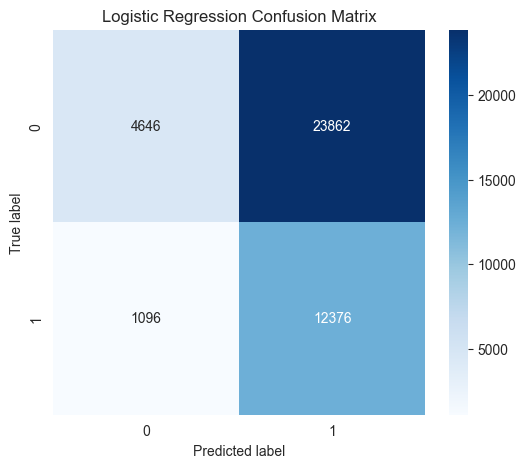

In [80]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

In [82]:
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

Accuracy: 0.7526202953787517

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.81      0.82     28508
           1       0.61      0.64      0.62     13472

    accuracy                           0.75     41980
   macro avg       0.72      0.72      0.72     41980
weighted avg       0.76      0.75      0.75     41980



In [83]:
cm_rf= confusion_matrix(y_test, y_pred)


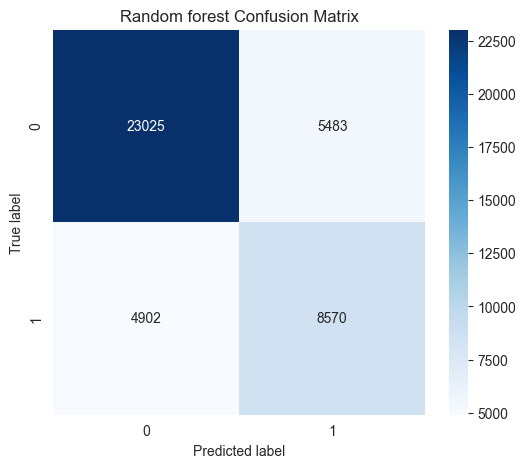

In [84]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random forest non eng Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [85]:
from xgboost import XGBClassifier
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [86]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [87]:

y_pred_xgb = xgb_model.predict(X_test)

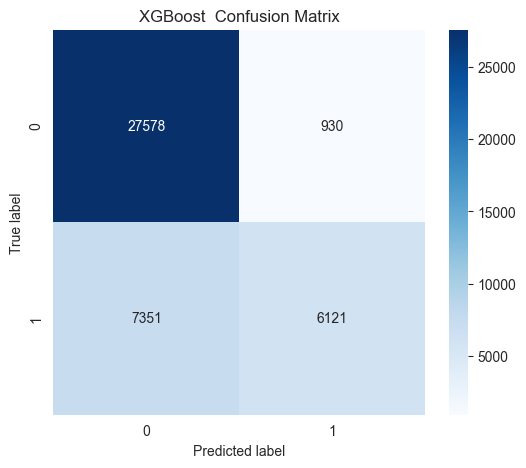

In [88]:
cm_rf= confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost  Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [89]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8027393997141496

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.97      0.87     28508
           1       0.87      0.45      0.60     13472

    accuracy                           0.80     41980
   macro avg       0.83      0.71      0.73     41980
weighted avg       0.81      0.80      0.78     41980



In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Preprocess
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

# 2. Scale
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn = scaler.transform(X_test_nn)

# 3. Build neural network
nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

y_prob_nn = nn_model.predict(X_test_nn)
y_pred_nn = (y_prob_nn > 0.5).astype(int).ravel()

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nn))

C:\Users\tedip\PycharmProjects\IntroInformedUninformed\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8284 - loss: 0.4031 - val_accuracy: 0.8657 - val_loss: 0.3273
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8791 - loss: 0.2850 - val_accuracy: 0.8699 - val_loss: 0.3204
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8917 - loss: 0.2487 - val_accuracy: 0.8388 - val_loss: 0.3542
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8994 - loss: 0.2276 - val_accuracy: 0.8418 - val_loss: 0.3564
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9076 - loss: 0.2089 - val_accuracy: 0.8476 - val_loss: 0.3585
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Accuracy: 0.8684135302525012

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.90     28508
           1       0.82      0.75      0.79     13472

    accuracy                           0.87     41980
   macro avg       0.85      0.84      

In [91]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
OneHotEncoder(handle_unknown="ignore", sparse_output=False)
OneHotEncoder(handle_unknown="ignore", sparse_output=False)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


history = nn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


y_prob_nn = nn_model.predict(X_test)
y_pred_nn = (y_prob_nn > 0.5).astype(int).ravel()


print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nn))

C:\Users\tedip\PycharmProjects\IntroInformedUninformed\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MemoryError: Unable to allocate 10.7 GiB for an array with shape (134335, 21454) and data type float32